# Semantic CRP

Semantic contiguity in successive recall transitions, measured as conditional response probability binned by cosine distance between clip embeddings. Shows whether participants tend to recall semantically similar clips in succession.

As with the lag-CRP, we examine semantic contiguity under multiple transition-type masks:

- **All transitions**: Standard semantic CRP.
- **Uncued**: Arriving recall had no preceding cue. Spontaneous semantic clustering.
- **Doubly uncued**: Neither end of the transition was cue-matched. Purest spontaneous semantic contiguity.
- **From-cued**: Departing recall matched its cue. Tests whether cue-reinstated context biases the next transition toward semantically related clips.

In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.analyses.conditional_distcrp import plot_dist_crp
from jaxcmr.helpers import find_project_root, load_data
from jaxcmr.selective_interference.analysis import (
    build_transition_masks,
    derive_cue_clips,
)

warnings.filterwarnings("ignore")

In [2]:
run_tag = "VRT_SEMANTIC_CRP"
data_path = "data/VRT_clips.h5"
features_path = "data/VRT_clip_embeddings.npy"
figure_dir = "results/figures"
figure_str = ""
ylim = None

## Setup and transition masks

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

features = np.load(os.path.join(project_root, features_path)).astype(np.float32)
print(f"Features shape: {features.shape}")

recalls = np.array(data["recalls"])
cue_clips = derive_cue_clips(
    np.array(data["recall_items"]),
    np.array(data["recall_types"]),
    recalls,
)
tmasks = build_transition_masks(recalls, cue_clips)

task = data["task"]
condition = data["condition"]
intervention = data["intervention"]

all_true = jnp.ones_like(data["recalls"], dtype=bool)

print(f"Loaded {recalls.shape[0]} trials")
for name, mask in tmasks.items():
    n = int(mask.sum())
    print(f"  {name}: {n} positions")


def trial_mask(mask):
    return jnp.asarray(mask).reshape(-1)


def summarize_masks(labels, masks):
    for label, mask in zip(labels, masks):
        n_trials = int(jnp.sum(mask))
        n_subjects = int(jnp.unique(data["subject"][mask]).size)
        print(f"{label}: trials={n_trials}, subjects={n_subjects}")


def plot_contrast(masks, labels, contrast_name, should_tab, axis=None, suffix=None):
    plot_dist_crp(
        datasets=[data] * len(masks),
        trial_masks=masks,
        should_tabulate=[should_tab] * len(masks),
        features=features,
        labels=labels,
        contrast_name=contrast_name,
        axis=axis,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    if axis is None:
        save_figure(figure_dir, figure_str, suffix=suffix or contrast_name)


def save_figure(fig_dir, fig_str, suffix=None):
    if not fig_str:
        plt.show()
        return
    os.makedirs(fig_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    path = os.path.join(fig_dir, f"{fig_str}{suffix_str}.png")
    plt.savefig(path, bbox_inches="tight", dpi=600)
    plt.show()

Features shape: (22, 768)
Loaded 240 trials
  uncued: 897 positions
  cue_matched: 891 positions
  doubly_uncued: 744 positions
  from_cued: 771 positions


## All transitions

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


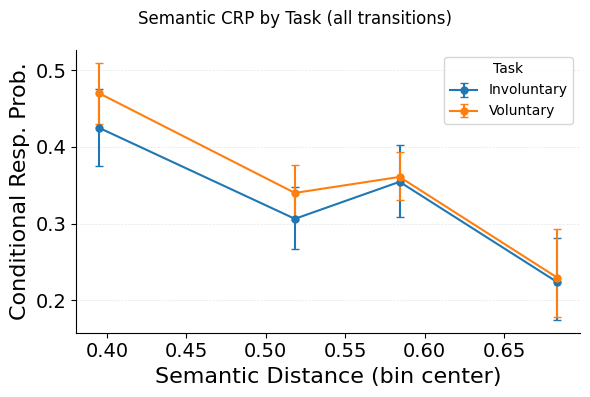

In [4]:
labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", all_true, axis=ax)
fig.suptitle("Semantic CRP by Task (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


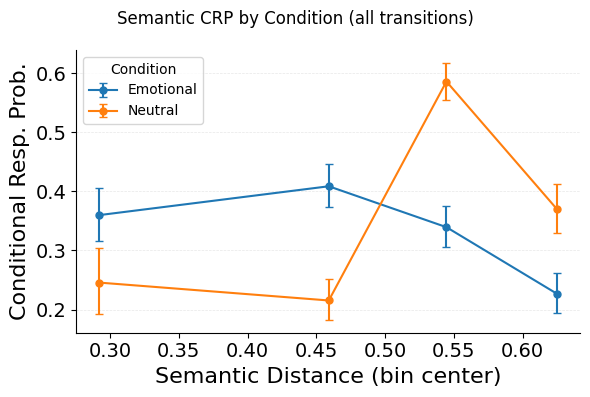

In [5]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", all_true, axis=ax)
fig.suptitle("Semantic CRP by Condition (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


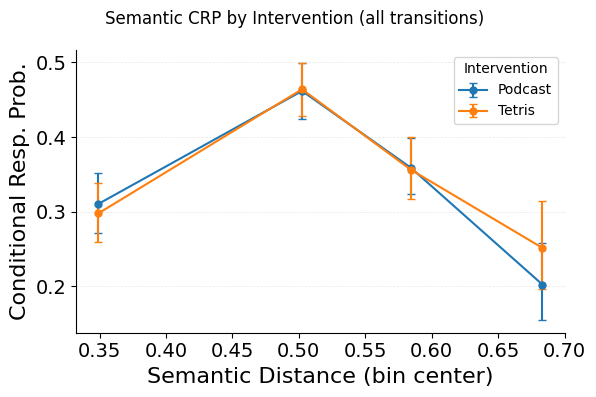

In [6]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", all_true, axis=ax)
fig.suptitle("Semantic CRP by Intervention (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_intervention")

Invol+Emotional: trials=60, subjects=60
Invol+Neutral: trials=60, subjects=60


Vol+Emotional: trials=60, subjects=60
Vol+Neutral: trials=60, subjects=60


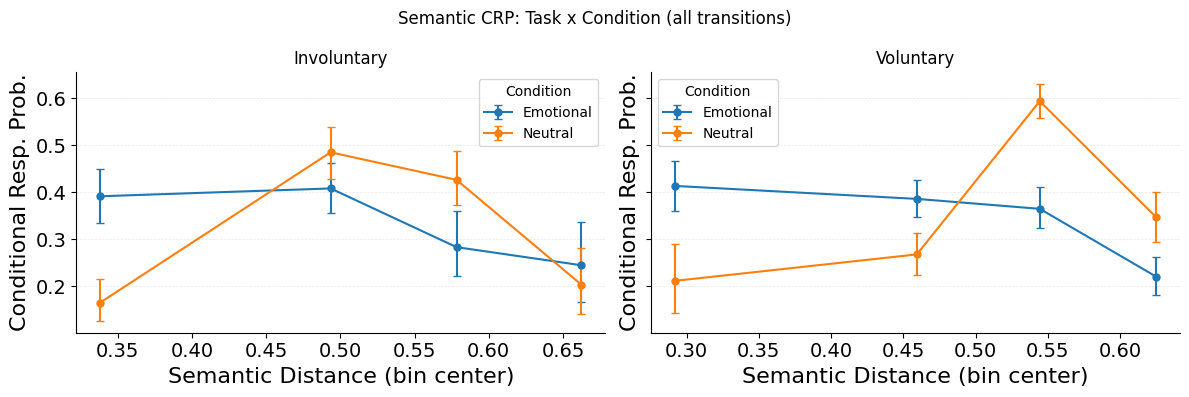

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

labels = ["Emotional", "Neutral"]
masks = [
    trial_mask((task == 1) & (condition == 1)),
    trial_mask((task == 1) & (condition == 2)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
plot_contrast(masks, labels, "Condition", all_true, axis=axes[0])
axes[0].set_title("Involuntary")

masks = [
    trial_mask((task == 2) & (condition == 1)),
    trial_mask((task == 2) & (condition == 2)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
plot_contrast(masks, labels, "Condition", all_true, axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Semantic CRP: Task x Condition (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_task_condition")

Invol+Podcast: trials=60, subjects=60
Invol+Tetris: trials=60, subjects=60


Vol+Podcast: trials=60, subjects=60
Vol+Tetris: trials=60, subjects=60


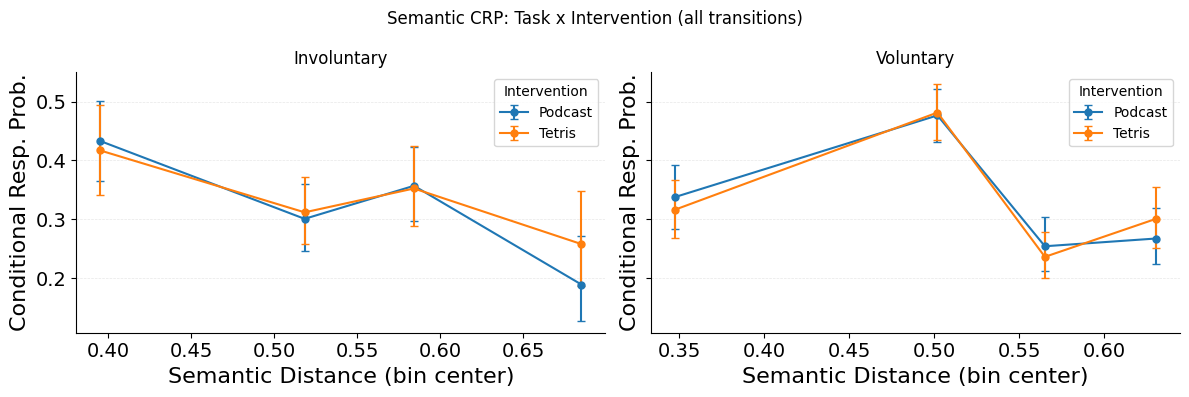

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

labels = ["Podcast", "Tetris"]
masks = [
    trial_mask((task == 1) & (intervention == 0)),
    trial_mask((task == 1) & (intervention == 1)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
plot_contrast(masks, labels, "Intervention", all_true, axis=axes[0])
axes[0].set_title("Involuntary")

masks = [
    trial_mask((task == 2) & (intervention == 0)),
    trial_mask((task == 2) & (intervention == 1)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
plot_contrast(masks, labels, "Intervention", all_true, axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Semantic CRP: Task x Intervention (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_task_intervention")

Emot+Podcast: trials=60, subjects=60
Emot+Tetris: trials=60, subjects=60


Neut+Podcast: trials=60, subjects=60
Neut+Tetris: trials=60, subjects=60


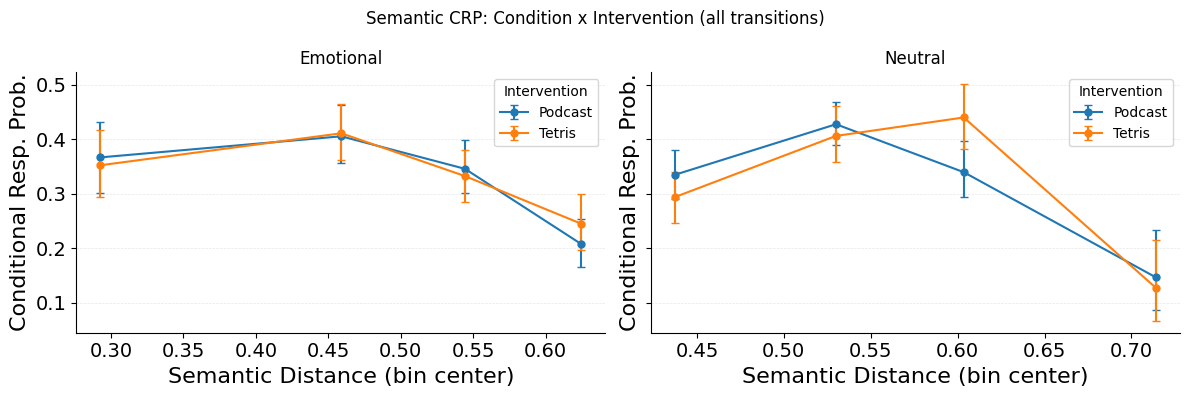

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

labels = ["Podcast", "Tetris"]
masks = [
    trial_mask((condition == 1) & (intervention == 0)),
    trial_mask((condition == 1) & (intervention == 1)),
]
summarize_masks([f"Emot+{l}" for l in labels], masks)
plot_contrast(masks, labels, "Intervention", all_true, axis=axes[0])
axes[0].set_title("Emotional")

masks = [
    trial_mask((condition == 2) & (intervention == 0)),
    trial_mask((condition == 2) & (intervention == 1)),
]
summarize_masks([f"Neut+{l}" for l in labels], masks)
plot_contrast(masks, labels, "Intervention", all_true, axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle("Semantic CRP: Condition x Intervention (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_condition_intervention")

## Uncued transitions

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


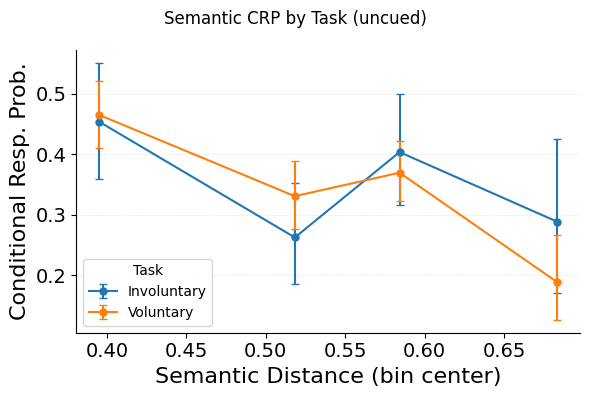

In [10]:
uncued = tmasks["uncued"]

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", uncued, axis=ax)
fig.suptitle("Semantic CRP by Task (uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


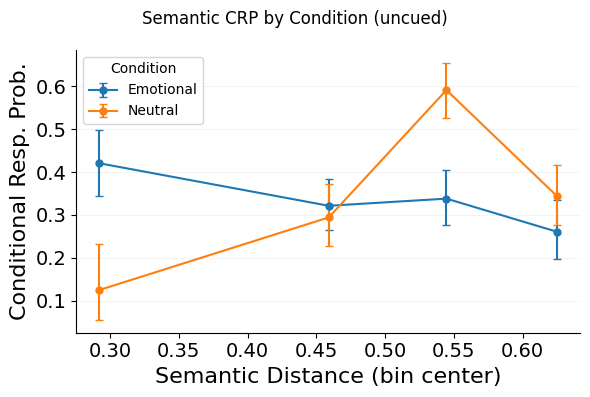

In [11]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", uncued, axis=ax)
fig.suptitle("Semantic CRP by Condition (uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


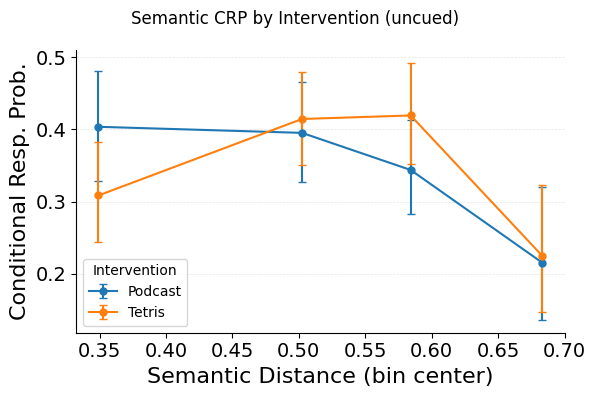

In [12]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", uncued, axis=ax)
fig.suptitle("Semantic CRP by Intervention (uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_intervention")

## Doubly uncued transitions

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


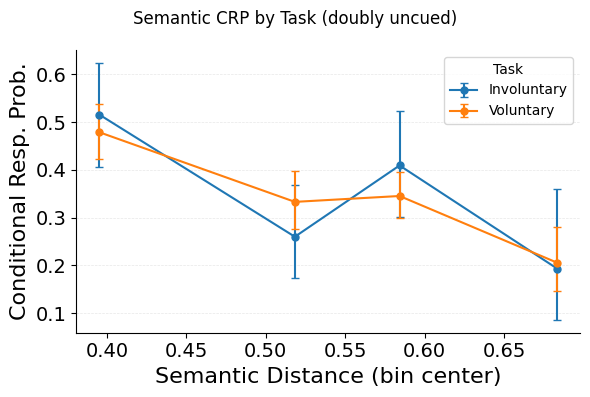

In [13]:
doubly_uncued = tmasks["doubly_uncued"]

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", doubly_uncued, axis=ax)
fig.suptitle("Semantic CRP by Task (doubly uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="doubly_uncued_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


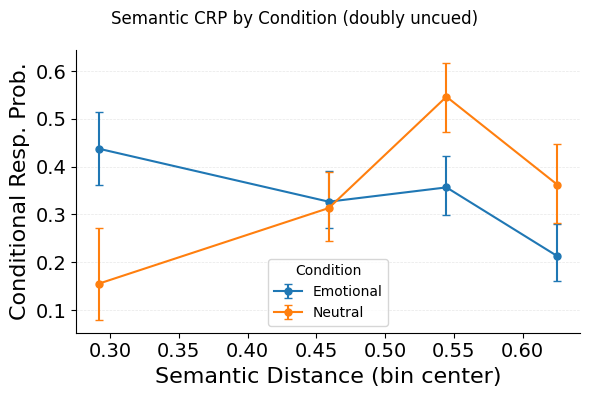

In [14]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", doubly_uncued, axis=ax)
fig.suptitle("Semantic CRP by Condition (doubly uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="doubly_uncued_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


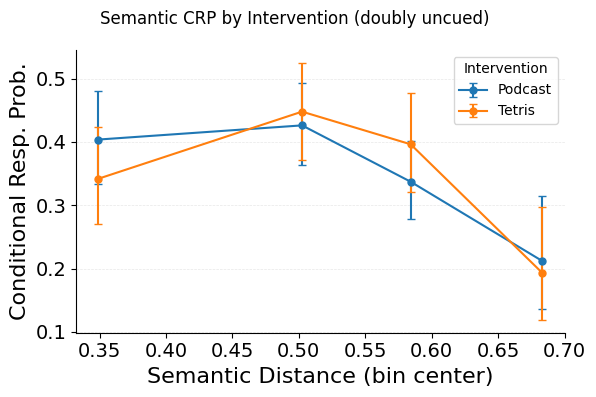

In [15]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", doubly_uncued, axis=ax)
fig.suptitle("Semantic CRP by Intervention (doubly uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="doubly_uncued_intervention")

## From-cued transitions

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


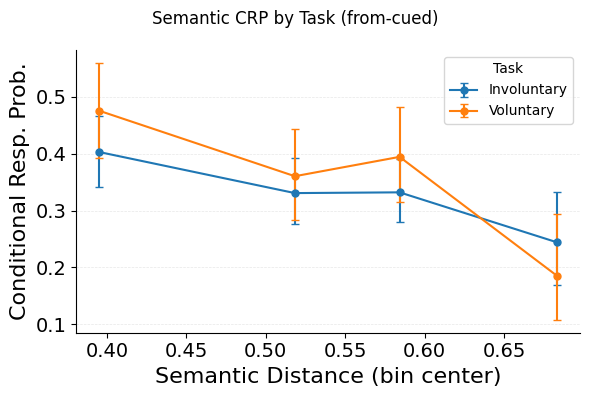

In [16]:
from_cued = tmasks["from_cued"]

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", from_cued, axis=ax)
fig.suptitle("Semantic CRP by Task (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


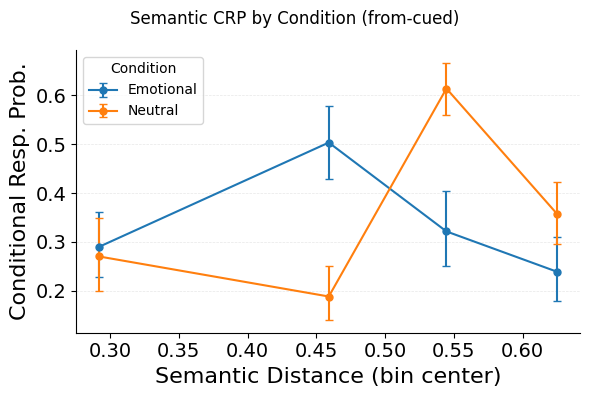

In [17]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", from_cued, axis=ax)
fig.suptitle("Semantic CRP by Condition (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


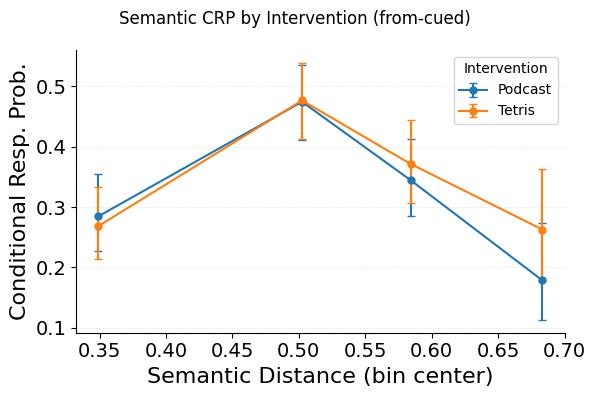

In [18]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", from_cued, axis=ax)
fig.suptitle("Semantic CRP by Intervention (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_intervention")